## Simulating traffic around a lock with a tide
In this notebook, we simulate a lock object on a network. Like in notebook 204, randomly generated, evenly sized vessels sampled from an exponential distribution have to pass this lock. We add a complex lock object to the graph. Vessels are levelled in the same lock operation if they can fit inside the lock and register with the lock operator before the start of the lock operation. We now include a tidal water level at one side of the lock, and we will observe the levelling times to fluctuate.

In [1]:
# package(s) used for creating and geo-locating the graph
import networkx as nx
import pyproj
from shapely.geometry import Point, LineString, Polygon
from shapely.ops import transform

# package(s) related to the simulation (creating the vessel, running the simulation)
import datetime
import simpy
import opentnsim
from opentnsim.core.utils import create_object
from opentnsim.graph import mixins as graph_module
from opentnsim.utils import inspect_object, generate_vessels_from_distribution
from opentnsim.core.logutils import logbook2eventtable
from opentnsim.core import Identifiable, Movable, VesselProperties, ExtraMetadata
from opentnsim.core.visualizations import generate_vessel_gantt_chart
from opentnsim.graph.mixins import HasMultiDiGraph
from opentnsim.output import HasOutput
from scipy.stats import norm, uniform, expon

# import of modules important for locking
from opentnsim.lock import IsLockChamber, IsLockWaitingArea, IsLockComplex, LockComplexTraversable
from opentnsim.lock.calculations import calculate_levelling_time
from opentnsim.environment.mixins.hydrodynamics import HydrodynamicData

# package(s) needed for inspecting the output
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# packege(s) needed to create hydrodynamic data
import xarray as xr

print("This notebook is executed with OpenTNSim version {}".format(opentnsim.__version__))

This notebook is executed with OpenTNSim version 1.3.4


In [2]:
%load_ext autoreload
%autoreload 2

#### 0. Create environment
We create an environment, it is important to define a simulation stop when working with hydrodynamic data.

In [3]:
# start simpy environment
simulation_start = datetime.datetime(2025, 1, 1, 0, 0, 0)
simulation_stop = datetime.datetime(2025, 1, 8, 0, 0, 0)
env = simpy.Environment(initial_time=simulation_start.timestamp())
env.simulation_start = simulation_start
env.simulation_stop = simulation_stop
env.epoch = simulation_start

#### 1. Create graph
We create a directional graph just like notebook 204.

In [4]:
# define reference systems
wgs84eqd = pyproj.CRS('4087')
wgs84rad = pyproj.CRS('4326')

# define transformer functions
wgs84eqd_to_wgs84rad = pyproj.transformer.Transformer.from_crs(wgs84eqd,wgs84rad,always_xy=True).transform #equidistant wgs84 to radial wgs84
wgs84rad_to_wgs84eqd = pyproj.transformer.Transformer.from_crs(wgs84rad,wgs84eqd,always_xy=True).transform #radial wgs84 to equidistant wgs84

# create a directed graph
graph = nx.DiGraph()

# add nodes
graph.add_node('-1',geometry=transform(wgs84eqd_to_wgs84rad,Point(-25000,0)))
graph.add_node('0',geometry=transform(wgs84eqd_to_wgs84rad,Point(-5000,0)))
graph.add_node('1',geometry=transform(wgs84eqd_to_wgs84rad,Point(5000,0)))
graph.add_node('+1',geometry=transform(wgs84eqd_to_wgs84rad,Point(25000,0)))

# add edges
graph.add_edge('-1','0', geometry = transform(wgs84eqd_to_wgs84rad, LineString([Point(-25000, 0),Point(-5000, 0)])), weight=1, length_m=25000-5000)
graph.add_edge('0','-1', geometry = transform(wgs84eqd_to_wgs84rad, LineString([Point(-5000, 0),Point(-25000, 0)])), weight=1, length_m=25000-5000)
graph.add_edge('0','1', geometry = transform(wgs84eqd_to_wgs84rad, LineString([Point(-5000, 0),Point(5000, 0)])), weight=1, length_m=10000)
graph.add_edge('1','0', geometry = transform(wgs84eqd_to_wgs84rad, LineString([Point(5000, 0),Point(-5000, 0)])), weight=1, length_m=10000)
graph.add_edge('1','+1', geometry = transform(wgs84eqd_to_wgs84rad, LineString([Point(5000, 0),Point(25000, 0)])), weight=1, length_m=25000-5000)
graph.add_edge('+1','1', geometry = transform(wgs84eqd_to_wgs84rad, LineString([Point(25000, 0),Point(5000, 0)])), weight=1, length_m=25000-5000)

# add graph to environment
env.graph = graph

In [5]:
graph_module.plot_graph(graph)

#### 1+ Adding environmental data
We now create a hydrodynamic data set with a sinusoidally fluctuating water level at node '1', and a static water level at node '0'.

In [6]:
hydrodynamic_data = xr.Dataset()

time = pd.date_range(start = simulation_start,
                     end = simulation_stop,
                     freq = pd.Timedelta(minutes=5))

static_water_level = np.zeros(len(time))
tidal_amplitude = 1.0
tidal_period = 12.5 #hours
tidal_water_level = [tidal_amplitude*np.sin(2*np.pi*(t-simulation_start).total_seconds()/(tidal_period*3600)) for t in time]

stations = ['0', '1']
water_level_data = xr.DataArray(data=[static_water_level,tidal_water_level],coords={'STATION':stations,'TIME':time})

hydrodynamic_data['Water level'] = water_level_data

We add the data to the environment as follows:

In [7]:
HydrodynamicData(env=env, hydrodynamic_data = hydrodynamic_data)

#### 1+ Adding infrastructure
We add the lock complex to the network:

In [8]:
lock_chamber = IsLockChamber(env=env,
                             lock_depth = 10,
                             name='Lock',
                             gate_open = '0',
                             edge = ('0','1'),
                             geometry_m = Polygon([Point(-200, -25),Point(-200, 25),Point(200, 25),Point(200, -25)]))

In [9]:
# The minimum required input for a lock complex are waiting areas at both sides of the lock
waiting_area_A = IsLockWaitingArea(env=env,
                                   name = 'Waiting area A',
                                   edge = ('0','1'),
                                   distance_from_edge_start = 0)

waiting_area_B = IsLockWaitingArea(env=env,
                                   name = 'Waiting area B',
                                   edge = ('1','0'),
                                   distance_from_edge_start = 0)

In [10]:
lock_complex = IsLockComplex(lock_chambers = [lock_chamber],
                             waiting_areas = [waiting_area_A, waiting_area_B],
                             registration_nodes = ['0','1'],
                             env=env,
                             name = 'Lock complex',)

#### 2. Create agents
And create agents from an exponential distribution

In [11]:
# make your preferred Vessel class out of available mix-ins.
Vessel = create_object(
    "Vessel", 
    (
        LockComplexTraversable,     # allows to interact with a lock
        Identifiable,               # allows to give the object a name and a random ID,
        Movable,                    # allows the object to move, with a fixed speed, while logging this activity
        VesselProperties,           # allows vessel to have dimensions, namely a length (L), width (B), and draught (T)
        ExtraMetadata,              # allow additional information, such as an arrival time (required for passing a lock)
        HasMultiDiGraph,            # allow to operate on a graph that can include parallel edges from and to the same nodes
        HasOutput,                  # allow additional output to be stored
    ), 
)

In [12]:
def mission(env, vessel):
    """
    Method that defines the mission of the vessel.
    
    In this case: 
        keep moving along the path until its end point is reached
    """
    while True:
        yield from vessel.move()
        
        if vessel.geometry == nx.get_node_attributes(env.graph, "geometry")[vessel.route[-1]]:
            break

In [13]:
upstream_vessels = generate_vessels_from_distribution(env=env,
                                                      VesselClass = Vessel,
                                                      vessel_parameters = {'v':4, 'L':100, 'B':20, 'T':5, 'type':'tanker'},
                                                      mean_arrival_rate=30.,
                                                      number_of_vessels=10,
                                                      start_node = '-1',
                                                      end_node = '+1',
                                                      seed = 123)

downstream_vessels = generate_vessels_from_distribution(env=env,
                                                        VesselClass = Vessel,
                                                        vessel_parameters = {'v':4, 'L':100, 'B':20, 'T':5, 'type':'tanker'},
                                                        mean_arrival_rate=30.,
                                                        number_of_vessels=10,
                                                        start_node = '+1',
                                                        end_node = '-1',
                                                        seed = 456)

vessels = upstream_vessels + downstream_vessels

for vessel in vessels:
    env.process(mission(env, vessel))

#### 3. Run simulation

In [14]:
env.run()

In [15]:
pd.DataFrame(lock_chamber.logbook)

,Message,Timestamp,Value,Geometry
0,Lock gate closing start,2025-01-01 01:38:04.354414,{},0
1,Lock gate closing stop,2025-01-01 01:43:04.354414,{},0
2,Lock levelling start,2025-01-01 01:43:04.354414,{},0
3,Lock levelling stop,2025-01-01 02:06:04.354414,{},1
4,Lock gate opening start,2025-01-01 02:06:04.354414,{},1
5,Lock gate opening stop,2025-01-01 02:11:04.354414,{},1
6,Lock gate closing start,2025-01-01 02:33:24.006006,{},1
7,Lock gate closing stop,2025-01-01 02:38:24.006006,{},1
8,Lock levelling start,2025-01-01 02:38:24.006006,{},1
9,Lock levelling stop,2025-01-01 03:04:44.006006,{},0


#### 4. Inspect output

##### Time-distance diagram of vessels passing the lock and planning info
We can get a time-distance diagram, including the water levels. We see that a different lock operation planning arises compared with Notebook 204.

In [16]:
def cm_to_pixels(cm):
    return cm * 37.8 # Set figure height to 10 cmfig.update_layout(height=cm_to_pixels(10))

# We can plot the time-distance diagram
fig = lock_chamber.plot(xlimmin = -6050, 
                        xlimmax = 6050,
                        ylimmin = pd.Timestamp('2025-01-01 00:00:00'),
                        ylimmax = pd.Timestamp('2025-01-01 10:00:00'),
                        method='Plotly',
                        boundary_nodes = ['-1','+1'])

fig.update_layout(height=cm_to_pixels(20))

##### Levelling durations as a function of water levels
We clearly see that the levelling duration depends on the lock head (the water level difference between the lock chamber and the harbour). We can visualise this using the following code:

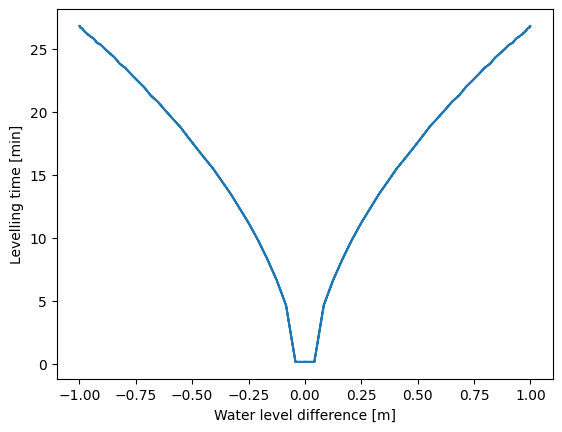

In [17]:
levelling_times = []
water_level_difference = []
stationA_index = np.where(np.array(list((hydrodynamic_data['STATION'].values))) == lock_chamber.start_node)[0][0]
stationB_index = np.where(np.array(list((hydrodynamic_data['STATION'].values))) == lock_chamber.end_node)[0][0]
H_A = hydrodynamic_data["Water level"][stationA_index].values.copy()
H_B = hydrodynamic_data["Water level"][stationB_index].values.copy()
for time in pd.date_range(pd.Timestamp('2025-01-01T00:00:00.000000000'),pd.Timestamp('2025-01-01T12:30:00.000000000'),freq=pd.Timedelta(minutes=5)):
    time_index = np.absolute(hydrodynamic_data['TIME'][:].values - np.datetime64(time)).argmin()
    wlev_A = H_A[time_index]
    wlev_B = H_B[time_index]
    wlev_dif = wlev_A - wlev_B
    water_level_difference.append(wlev_dif)
    levelling_times.append(calculate_levelling_time(lock_chamber, t_start = time,direction=1,wlev_init=wlev_dif,prediction=True)[0])

plt.plot(water_level_difference,np.array(levelling_times)/60)
plt.xlabel('Water level difference [m]')
plt.ylabel('Levelling time [min]');

We can also observe the detailed water level difference over time (see section 4.4.6 of lecture notes, and figure 4.4.2). We find that the lock valves (through which the water is either entering or leaving the lock) slowly open, as initially the levelling speed accelerates (the values are steadily increasing in cross-section). Moreover, the smaller the lock head, the slower the levelling speed. As the last 5 cm of the lock head will take a very long time to level, lock doors are generally opened before the lock has been fully levelled, conditional on the forces on the moored vessels due to the resulting translation wave being acceptable.

Text(0, 0.5, 'Lock head [m]')

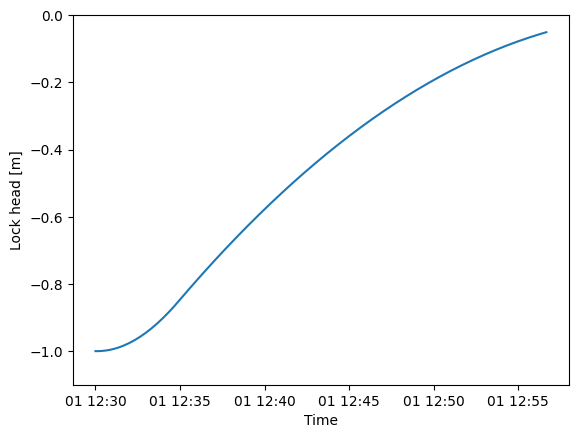

In [18]:
_, t,z = calculate_levelling_time(lock_chamber, t_start = time,direction=1,wlev_init=1,prediction=True)
plt.plot(t,z)
plt.ylim(-1.1,0)
plt.xlabel('Time')
plt.ylabel('Lock head [m]')